# Reflection / Glare Removal Pipeline for Fingernail ROI Images

Goal: remove **high-confidence specular glare** while preserving nail color quality for anemia prediction.

Why this version exists:
- The older HSV rule treated many bright/low-saturation pixels as glare.
- For anemia prediction, **diffuse pallor can be real signal**, especially when the nailbed looks pale.
- Pressure on the nail can also create pale/blanched regions that should be reviewed, not automatically erased.

Core rule:
- **Background** → ignored through alpha / foreground mask
- **High-confidence specular glare** → inpaint if small, soften if moderate, flag if too large
- **Diffuse pale / possible pressure regions** → preserved, saved as a review mask, never removed automatically

Outputs:
- processed PNG images
- optional RGBA images where only high-confidence glare/background are transparent
- high-confidence glare masks
- pale/pressure review masks
- before/after previews
- `reflection_report.csv`
- `pipeline_config.json`
- `reflection_review_contact_sheet.png`

This notebook does **not resize** images and saves processed outputs as **PNG** to avoid quality loss.

In [1]:
# Install dependencies if needed
# In Colab, uncomment:
# !pip install opencv-python pillow pandas tqdm matplotlib

import os
import shutil
import json
from pathlib import Path
import cv2
import numpy as np
import pandas as pd
from PIL import Image, ImageOps, ImageDraw
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

print("Ready.")

/opt/anaconda3/envs/nail_preprocess/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Ready.


## 1. Configure paths

Set `INPUT_DIR` to the folder containing your cropped nail ROI images.

Recommended input: output from your ROI segmentation / brightening pipeline.

This version is intentionally more conservative than the earlier glare-removal notebook. It should remove fewer pixels, but the pixels it removes are more likely to be true specular reflection rather than useful pale nailbed signal.

In [2]:
# ===== USER SETTINGS =====

INPUT_DIR = Path('/Users/williamtsai/Desktop/NTHU 3.2/special topic/will_data/pre_process/brighten/usable_nail_crops_roi102_flat_images_brightened')   # change this
OUTPUT_DIR = Path('/Users/williamtsai/Desktop/NTHU 3.2/special topic/will_data/pre_process/glare/usable_nail_crops_roi102_flat_images_brightened_reflection_refined_output')  # change this

# Save organization
PROCESSED_DIR = OUTPUT_DIR / "processed_png"
RGBA_IGNORE_DIR = OUTPUT_DIR / "rgba_ignore_png"
MASK_DIR = OUTPUT_DIR / "masks"
PREVIEW_DIR = OUTPUT_DIR / "previews"
UNUSABLE_DIR = OUTPUT_DIR / "unusable_too_much_specular_glare"
REVIEW_DIR = OUTPUT_DIR / "review_pale_or_pressure_possible"

# Supported inputs; all processed outputs are saved as PNG
IMAGE_EXTS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff", ".webp"}

# -----------------------------
# High-confidence specular glare settings
# -----------------------------
# Stricter than the older V>220 / S<60 rule.
# This is designed to avoid deleting diffuse pallor.
SPECULAR_V_ABS = 235
SPECULAR_S_MAX = 55
SPECULAR_ADAPTIVE_PERCENTILE = 98.5

# Local contrast rule: true glare is usually a sharp local highlight.
# Diffuse pallor usually has lower top-hat / local contrast.
LOCAL_MEDIAN_KERNEL = 15
SPECULAR_TOPHAT_MIN = 18

# Near-white core rule catches saturated reflection even if local contrast is not huge.
WHITE_CORE_V_MIN = 245
WHITE_CORE_S_MAX = 40
WHITE_CORE_RGB_SPREAD_MAX = 28

# Remove tiny noise components from the glare mask.
MIN_GLARE_COMPONENT_AREA = 6

# Method thresholds, percent of foreground/nail area.
# Conservative default: large modified area means "review", not fake repair.
SMALL_GLARE_PERCENT = 3.0      # <= this: inpaint
LARGE_GLARE_PERCENT = 8.0      # <= this: soften; > this: mark unusable / copy original

# Mask post-processing. Keep dilation weak to avoid eating pale/pressure pixels.
DILATE_KERNEL_SIZE = 3
DILATE_ITERATIONS = 1

# Inpainting settings
INPAINT_RADIUS = 3
INPAINT_METHOD = cv2.INPAINT_TELEA  # cv2.INPAINT_NS is another option

# Softening settings
SOFTEN_BLEND_STRENGTH = 0.55
# Higher means stronger replacement of glare brightness by a local estimate.

# -----------------------------
# Diffuse pale / pressure-review settings
# -----------------------------
# These pixels are NOT removed. They are only saved as a separate review mask.
PALE_V_PERCENTILE = 75
PALE_S_MAX = 95
PALE_TOPHAT_MAX = 14
PALE_REVIEW_PERCENT = 8.0

# Optional RGBA output for a 4-channel CNN:
# background remains transparent; high-confidence glare becomes transparent;
# diffuse pale/pressure pixels stay valid/opaque.
SAVE_RGBA_IGNORE_OUTPUT = True
MAKE_GLARE_TRANSPARENT_IN_RGBA = True

# Preview settings
MAKE_PREVIEWS = True
MAKE_CONTACT_SHEET = True
CONTACT_SHEET_MAX_IMAGES = 80

for d in [PROCESSED_DIR, RGBA_IGNORE_DIR, MASK_DIR, PREVIEW_DIR, UNUSABLE_DIR, REVIEW_DIR]:
    d.mkdir(parents=True, exist_ok=True)

PIPELINE_CONFIG = {
    "SPECULAR_V_ABS": SPECULAR_V_ABS,
    "SPECULAR_S_MAX": SPECULAR_S_MAX,
    "SPECULAR_ADAPTIVE_PERCENTILE": SPECULAR_ADAPTIVE_PERCENTILE,
    "LOCAL_MEDIAN_KERNEL": LOCAL_MEDIAN_KERNEL,
    "SPECULAR_TOPHAT_MIN": SPECULAR_TOPHAT_MIN,
    "WHITE_CORE_V_MIN": WHITE_CORE_V_MIN,
    "WHITE_CORE_S_MAX": WHITE_CORE_S_MAX,
    "WHITE_CORE_RGB_SPREAD_MAX": WHITE_CORE_RGB_SPREAD_MAX,
    "MIN_GLARE_COMPONENT_AREA": MIN_GLARE_COMPONENT_AREA,
    "SMALL_GLARE_PERCENT": SMALL_GLARE_PERCENT,
    "LARGE_GLARE_PERCENT": LARGE_GLARE_PERCENT,
    "DILATE_KERNEL_SIZE": DILATE_KERNEL_SIZE,
    "DILATE_ITERATIONS": DILATE_ITERATIONS,
    "PALE_V_PERCENTILE": PALE_V_PERCENTILE,
    "PALE_S_MAX": PALE_S_MAX,
    "PALE_TOPHAT_MAX": PALE_TOPHAT_MAX,
    "PALE_REVIEW_PERCENT": PALE_REVIEW_PERCENT,
    "SAVE_RGBA_IGNORE_OUTPUT": SAVE_RGBA_IGNORE_OUTPUT,
    "MAKE_GLARE_TRANSPARENT_IN_RGBA": MAKE_GLARE_TRANSPARENT_IN_RGBA,
}

with open(OUTPUT_DIR / "pipeline_config.json", "w", encoding="utf-8") as f:
    json.dump(PIPELINE_CONFIG, f, indent=2)

print("Input :", INPUT_DIR)
print("Output:", OUTPUT_DIR)
print("Config saved to:", OUTPUT_DIR / "pipeline_config.json")

Input : /Users/williamtsai/Desktop/NTHU 3.2/special topic/will_data/pre_process/brighten/usable_nail_crops_roi102_flat_images_brightened
Output: /Users/williamtsai/Desktop/NTHU 3.2/special topic/will_data/pre_process/glare/usable_nail_crops_roi102_flat_images_brightened_reflection_refined_output
Config saved to: /Users/williamtsai/Desktop/NTHU 3.2/special topic/will_data/pre_process/glare/usable_nail_crops_roi102_flat_images_brightened_reflection_refined_output/pipeline_config.json


## 2. Helper functions

Main idea:
1. Preserve alpha if the input PNG has transparency.
2. Build a foreground/nail mask so background is not processed.
3. Detect **high-confidence specular glare** using brightness, low saturation, local contrast, and near-white-core rules.
4. Separately detect **diffuse pale / possible pressure regions** for review only.
5. Modify only the high-confidence glare mask. Never modify the pale/pressure review mask.

In [3]:
def list_images(input_dir: Path):
    return sorted([p for p in input_dir.rglob("*") if p.suffix.lower() in IMAGE_EXTS])


def safe_odd_kernel(requested, height, width):
    """Return a safe odd kernel size for median filtering."""
    max_allowed = max(1, min(height, width))
    if max_allowed % 2 == 0:
        max_allowed -= 1
    k = min(int(requested), max_allowed)
    if k % 2 == 0:
        k -= 1
    return max(k, 1)


def read_image_preserve_alpha(path: Path):
    """
    Returns:
        bgr: uint8 BGR image, HxWx3
        alpha: uint8 alpha channel or None
        original_mode: PIL mode string
    """
    pil = Image.open(path)
    original_mode = pil.mode
    pil = ImageOps.exif_transpose(pil)

    if pil.mode in ("RGBA", "LA"):
        rgba = pil.convert("RGBA")
        arr = np.array(rgba)
        rgb = arr[:, :, :3]
        alpha = arr[:, :, 3]
    else:
        rgb = np.array(pil.convert("RGB"))
        alpha = None

    bgr = cv2.cvtColor(rgb, cv2.COLOR_RGB2BGR)
    return bgr, alpha, original_mode


def make_foreground_mask(bgr, alpha=None):
    """
    Foreground/nail mask.
    If alpha exists, use alpha > 0.
    Otherwise, treat near-black padding as background.
    """
    if alpha is not None:
        fg = alpha > 0
    else:
        gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
        fg = gray > 5

    fg_u8 = (fg.astype(np.uint8) * 255)
    kernel = np.ones((3, 3), np.uint8)
    fg_u8 = cv2.morphologyEx(fg_u8, cv2.MORPH_CLOSE, kernel, iterations=1)
    return fg_u8 > 0


def filter_components(mask_bool, min_area=6):
    """Remove tiny components from a binary mask."""
    mask_u8 = (mask_bool.astype(np.uint8) * 255)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask_u8, connectivity=8)
    kept = np.zeros_like(mask_bool, dtype=bool)
    component_areas = []

    for label in range(1, num_labels):
        area = int(stats[label, cv2.CC_STAT_AREA])
        if area >= min_area:
            kept[labels == label] = True
            component_areas.append(area)

    return kept, component_areas


def detect_reflection_and_pallor_masks(bgr, foreground_mask):
    """
    Returns:
        glare_mask_u8: high-confidence specular glare mask, uint8 0/255
        pale_mask_u8: diffuse pale / possible pressure mask, uint8 0/255, review only
        det_info: dictionary of thresholds and component statistics

    Design logic:
    - Specular glare should be bright, low-saturation, and either locally sharp
      or near-white/saturated.
    - Diffuse pallor/pressure should be preserved. It may be bright and low-saturation,
      but it is usually less locally sharp, so it is saved separately for review.
    """
    hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)
    h, s, v = cv2.split(hsv)
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

    fg = foreground_mask.astype(bool)
    empty = np.zeros(fg.shape, dtype=np.uint8)

    if fg.sum() == 0:
        return empty, empty, {
            "adaptive_v_threshold": np.nan,
            "pale_v_threshold": np.nan,
            "raw_glare_pixels": 0,
            "kept_glare_components": 0,
            "kept_glare_component_area_max": 0,
            "white_core_pixels": 0,
            "sharp_highlight_pixels": 0,
            "pale_review_pixels": 0,
        }

    # Local top-hat-like contrast using median background.
    k = safe_odd_kernel(LOCAL_MEDIAN_KERNEL, bgr.shape[0], bgr.shape[1])
    if k > 1:
        local_median = cv2.medianBlur(v, k)
    else:
        local_median = v.copy()
    top_hat = v.astype(np.int16) - local_median.astype(np.int16)

    v_fg = v[fg]
    adaptive_v = float(np.percentile(v_fg, SPECULAR_ADAPTIVE_PERCENTILE))
    pale_v = float(np.percentile(v_fg, PALE_V_PERCENTILE))

    rgb_max = rgb.max(axis=2)
    rgb_min = rgb.min(axis=2)
    rgb_spread = rgb_max - rgb_min

    # Very conservative specular rules.
    high_value = (v >= max(SPECULAR_V_ABS, adaptive_v))
    low_sat = (s <= SPECULAR_S_MAX)
    sharp_local = (top_hat >= SPECULAR_TOPHAT_MIN)

    sharp_highlight = high_value & low_sat & sharp_local & fg

    white_core = (
        (v >= WHITE_CORE_V_MIN) &
        (s <= WHITE_CORE_S_MAX) &
        (rgb_spread <= WHITE_CORE_RGB_SPREAD_MAX) &
        fg
    )

    glare_raw = (sharp_highlight | white_core) & fg
    glare_kept, component_areas = filter_components(glare_raw, MIN_GLARE_COMPONENT_AREA)

    # Dilate only after strict detection, so borders of true glare are handled.
    glare = glare_kept.copy()
    if DILATE_KERNEL_SIZE > 0 and DILATE_ITERATIONS > 0 and glare.any():
        kernel = np.ones((DILATE_KERNEL_SIZE, DILATE_KERNEL_SIZE), np.uint8)
        glare_u8 = cv2.dilate((glare.astype(np.uint8) * 255), kernel, iterations=DILATE_ITERATIONS)
        glare = (glare_u8 > 0) & fg

    # Pale/pressure review mask: bright + low-ish saturation, but not sharp glare.
    # This is intentionally NOT used for editing.
    diffuse_bright = (v >= pale_v) & (s <= PALE_S_MAX) & fg
    not_sharp = top_hat <= PALE_TOPHAT_MAX
    pale_review = diffuse_bright & not_sharp & (~glare)

    pale_u8 = (pale_review.astype(np.uint8) * 255)
    if pale_review.any():
        kernel = np.ones((3, 3), np.uint8)
        pale_u8 = cv2.morphologyEx(pale_u8, cv2.MORPH_OPEN, kernel, iterations=1)
        pale_u8 = cv2.morphologyEx(pale_u8, cv2.MORPH_CLOSE, kernel, iterations=1)
        pale_review = pale_u8 > 0

    glare_u8 = (glare.astype(np.uint8) * 255)
    pale_u8 = (pale_review.astype(np.uint8) * 255)

    return glare_u8, pale_u8, {
        "adaptive_v_threshold": adaptive_v,
        "pale_v_threshold": pale_v,
        "local_median_kernel_used": int(k),
        "raw_glare_pixels": int(glare_raw.sum()),
        "kept_glare_components": int(len(component_areas)),
        "kept_glare_component_area_max": int(max(component_areas) if component_areas else 0),
        "white_core_pixels": int(white_core.sum()),
        "sharp_highlight_pixels": int(sharp_highlight.sum()),
        "pale_review_pixels": int(pale_review.sum()),
    }


def area_percent(mask_u8, foreground_mask):
    fg_area = int(foreground_mask.sum())
    area = int((mask_u8 > 0).sum())
    if fg_area == 0:
        return 0.0, area, fg_area
    return 100.0 * area / fg_area, area, fg_area


def choose_method(glare_pct):
    if glare_pct <= 0:
        return "none", "ok_no_high_conf_glare"
    if glare_pct <= SMALL_GLARE_PERCENT:
        return "inpaint", "ok_high_conf_glare_inpainted"
    if glare_pct <= LARGE_GLARE_PERCENT:
        return "soften", "warning_large_high_conf_glare_softened"
    return "copy_original", "unusable_too_much_specular_glare"


def inpaint_glare(bgr, mask_u8):
    if (mask_u8 > 0).sum() == 0:
        return bgr.copy()
    return cv2.inpaint(bgr, mask_u8, INPAINT_RADIUS, INPAINT_METHOD)


def soften_glare(bgr, mask_u8, foreground_mask):
    """
    Safer than full inpainting for moderate glare:
    reduce brightness in glare regions using a blurred local estimate,
    while preserving some original color/texture.
    """
    mask = mask_u8 > 0
    if mask.sum() == 0:
        return bgr.copy()

    local = cv2.medianBlur(bgr, 9)
    local = cv2.GaussianBlur(local, (0, 0), sigmaX=5, sigmaY=5)

    out = bgr.copy().astype(np.float32)
    local_f = local.astype(np.float32)

    out[mask] = (1 - SOFTEN_BLEND_STRENGTH) * out[mask] + SOFTEN_BLEND_STRENGTH * local_f[mask]

    hsv = cv2.cvtColor(np.clip(out, 0, 255).astype(np.uint8), cv2.COLOR_BGR2HSV).astype(np.float32)
    h, s, v = cv2.split(hsv)
    if foreground_mask.sum() > 0:
        v_cap = np.percentile(v[foreground_mask], 90)
        v[mask] = np.minimum(v[mask], v_cap)
    hsv2 = cv2.merge([h, s, v]).astype(np.uint8)
    out2 = cv2.cvtColor(hsv2, cv2.COLOR_HSV2BGR)

    return out2


def make_output_alpha(alpha, foreground_mask, glare_mask_u8=None):
    """
    Create alpha for RGBA ignore-output.
    - If original alpha exists, preserve it.
    - Otherwise, foreground becomes opaque and background transparent.
    - Optional: high-confidence glare becomes transparent.
    """
    if alpha is not None:
        out_alpha = alpha.copy()
    else:
        out_alpha = np.where(foreground_mask, 255, 0).astype(np.uint8)

    if MAKE_GLARE_TRANSPARENT_IN_RGBA and glare_mask_u8 is not None:
        out_alpha[glare_mask_u8 > 0] = 0

    return out_alpha


def save_png_preserve_alpha(bgr, alpha, out_path: Path):
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    if alpha is not None:
        rgba = np.dstack([rgb, alpha])
        Image.fromarray(rgba, mode="RGBA").save(out_path)
    else:
        Image.fromarray(rgb, mode="RGB").save(out_path)


def save_rgba_with_alpha(bgr, alpha_u8, out_path: Path):
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    rgba = np.dstack([rgb, alpha_u8])
    Image.fromarray(rgba, mode="RGBA").save(out_path)


def save_mask(mask_u8, out_path: Path):
    Image.fromarray(mask_u8).save(out_path)


def make_preview(original_bgr, processed_bgr, glare_mask_u8, pale_mask_u8, out_path: Path):
    orig_rgb = cv2.cvtColor(original_bgr, cv2.COLOR_BGR2RGB)
    proc_rgb = cv2.cvtColor(processed_bgr, cv2.COLOR_BGR2RGB)

    mask_rgb = np.zeros_like(orig_rgb)
    mask_rgb[:, :, 0] = glare_mask_u8       # red = high-confidence glare
    mask_rgb[:, :, 2] = pale_mask_u8        # blue = pale/pressure review

    overlay = orig_rgb.copy().astype(np.float32)
    glare = glare_mask_u8 > 0
    pale = (pale_mask_u8 > 0) & (~glare)
    overlay[glare] = 0.55 * overlay[glare] + 0.45 * np.array([255, 0, 0], dtype=np.float32)
    overlay[pale] = 0.60 * overlay[pale] + 0.40 * np.array([0, 80, 255], dtype=np.float32)

    panels = [
        Image.fromarray(orig_rgb),
        Image.fromarray(mask_rgb),
        Image.fromarray(np.clip(overlay, 0, 255).astype(np.uint8)),
        Image.fromarray(proc_rgb),
    ]

    h = max(p.height for p in panels)
    resized = []
    for p in panels:
        if p.height != h:
            new_w = int(p.width * h / p.height)
            p = p.resize((new_w, h))
        resized.append(p)

    total_w = sum(p.width for p in resized)
    canvas = Image.new("RGB", (total_w, h + 32), "white")
    draw = ImageDraw.Draw(canvas)
    labels = ["original", "red=glare blue=pale_review", "overlay", "processed"]

    x = 0
    for label, p in zip(labels, resized):
        canvas.paste(p, (x, 32))
        draw.text((x + 5, 7), label, fill=(0, 0, 0))
        x += p.width

    canvas.save(out_path)


def file_stem_safe(path: Path):
    return path.stem.replace(" ", "_")

## 3. Run the refined pipeline

This run produces two main image outputs:

1. `processed_png`: normal RGB/RGBA processed images. Small high-confidence glare may be inpainted; moderate glare may be softened.
2. `rgba_ignore_png`: optional 4-channel images where background and high-confidence glare are transparent. Diffuse pale/pressure pixels stay opaque because they may contain anemia-related signal.

In [4]:
image_paths = list_images(INPUT_DIR)
print(f"Found {len(image_paths)} images.")

records = []

for img_path in tqdm(image_paths):
    try:
        bgr, alpha, original_mode = read_image_preserve_alpha(img_path)
        fg = make_foreground_mask(bgr, alpha)

        glare_mask, pale_mask, det_info = detect_reflection_and_pallor_masks(bgr, fg)
        gpct, glare_area, fg_area = area_percent(glare_mask, fg)
        ppct, pale_area, _ = area_percent(pale_mask, fg)
        method, status = choose_method(gpct)
        pale_pressure_review = bool(ppct >= PALE_REVIEW_PERCENT)

        if method == "none":
            processed = bgr.copy()
        elif method == "inpaint":
            processed = inpaint_glare(bgr, glare_mask)
        elif method == "soften":
            processed = soften_glare(bgr, glare_mask, fg)
        elif method == "copy_original":
            processed = bgr.copy()
        else:
            processed = bgr.copy()

        stem = file_stem_safe(img_path)
        out_name = stem + ".png"
        processed_path = PROCESSED_DIR / out_name
        rgba_ignore_path = RGBA_IGNORE_DIR / out_name
        glare_mask_path = MASK_DIR / (stem + "_high_conf_glare_mask.png")
        pale_mask_path = MASK_DIR / (stem + "_pale_pressure_review_mask.png")
        preview_path = PREVIEW_DIR / (stem + "_preview.png")

        save_png_preserve_alpha(processed, alpha, processed_path)
        save_mask(glare_mask, glare_mask_path)
        save_mask(pale_mask, pale_mask_path)

        if SAVE_RGBA_IGNORE_OUTPUT:
            out_alpha = make_output_alpha(alpha, fg, glare_mask)
            # For RGBA ignore-output, keep the original color signal and only encode invalid pixels in alpha.
            save_rgba_with_alpha(bgr, out_alpha, rgba_ignore_path)
        else:
            rgba_ignore_path = Path("")

        if MAKE_PREVIEWS:
            make_preview(bgr, processed, glare_mask, pale_mask, preview_path)

        if status == "unusable_too_much_specular_glare":
            shutil.copy2(img_path, UNUSABLE_DIR / img_path.name)

        if pale_pressure_review:
            shutil.copy2(img_path, REVIEW_DIR / img_path.name)

        records.append({
            "filename": img_path.name,
            "input_path": str(img_path),
            "processed_path": str(processed_path),
            "rgba_ignore_path": str(rgba_ignore_path) if SAVE_RGBA_IGNORE_OUTPUT else "",
            "glare_mask_path": str(glare_mask_path),
            "pale_pressure_mask_path": str(pale_mask_path),
            "preview_path": str(preview_path) if MAKE_PREVIEWS else "",
            "original_mode": original_mode,
            "width": int(bgr.shape[1]),
            "height": int(bgr.shape[0]),
            "foreground_area_pixels": fg_area,
            "high_conf_glare_area_pixels": glare_area,
            "high_conf_glare_area_percent": round(gpct, 4),
            "pale_pressure_area_pixels": pale_area,
            "pale_pressure_area_percent": round(ppct, 4),
            "pale_pressure_review": pale_pressure_review,
            "method_used": method,
            "status": status,
            "adaptive_v_threshold": det_info["adaptive_v_threshold"],
            "pale_v_threshold": det_info["pale_v_threshold"],
            "local_median_kernel_used": det_info["local_median_kernel_used"],
            "raw_glare_pixels": det_info["raw_glare_pixels"],
            "white_core_pixels": det_info["white_core_pixels"],
            "sharp_highlight_pixels": det_info["sharp_highlight_pixels"],
            "kept_glare_components": det_info["kept_glare_components"],
            "kept_glare_component_area_max": det_info["kept_glare_component_area_max"],
        })

    except Exception as e:
        records.append({
            "filename": img_path.name,
            "input_path": str(img_path),
            "processed_path": "",
            "rgba_ignore_path": "",
            "glare_mask_path": "",
            "pale_pressure_mask_path": "",
            "preview_path": "",
            "original_mode": "",
            "width": "",
            "height": "",
            "foreground_area_pixels": "",
            "high_conf_glare_area_pixels": "",
            "high_conf_glare_area_percent": "",
            "pale_pressure_area_pixels": "",
            "pale_pressure_area_percent": "",
            "pale_pressure_review": "",
            "method_used": "error",
            "status": f"error: {repr(e)}",
            "adaptive_v_threshold": "",
            "pale_v_threshold": "",
            "local_median_kernel_used": "",
            "raw_glare_pixels": "",
            "white_core_pixels": "",
            "sharp_highlight_pixels": "",
            "kept_glare_components": "",
            "kept_glare_component_area_max": "",
        })

report_df = pd.DataFrame(records)
report_path = OUTPUT_DIR / "reflection_report.csv"
report_df.to_csv(report_path, index=False, encoding="utf-8-sig")

print("Done.")
print("Report saved to:", report_path)
display(report_df.head())

Found 3467 images.


100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 3467/3467 [01:52<00:00, 30.72it/s]


Done.
Report saved to: /Users/williamtsai/Desktop/NTHU 3.2/special topic/will_data/pre_process/glare/usable_nail_crops_roi102_flat_images_brightened_reflection_refined_output/reflection_report.csv


,filename,input_path,processed_path,rgba_ignore_path,glare_mask_path,pale_pressure_mask_path,preview_path,original_mode,width,height,...,method_used,status,adaptive_v_threshold,pale_v_threshold,local_median_kernel_used,raw_glare_pixels,white_core_pixels,sharp_highlight_pixels,kept_glare_components,kept_glare_component_area_max
0,20210607132915_pid2625_eowkBq_nail_01.png,/Users/williamtsai/Desktop/NTHU 3.2/special to...,/Users/williamtsai/Desktop/NTHU 3.2/special to...,/Users/williamtsai/Desktop/NTHU 3.2/special to...,/Users/williamtsai/Desktop/NTHU 3.2/special to...,/Users/williamtsai/Desktop/NTHU 3.2/special to...,/Users/williamtsai/Desktop/NTHU 3.2/special to...,RGB,371,381,...,none,ok_no_high_conf_glare,164.0,151.0,15,0,0,0,0,0
1,20210607132915_pid2625_eowkBq_nail_02.png,/Users/williamtsai/Desktop/NTHU 3.2/special to...,/Users/williamtsai/Desktop/NTHU 3.2/special to...,/Users/williamtsai/Desktop/NTHU 3.2/special to...,/Users/williamtsai/Desktop/NTHU 3.2/special to...,/Users/williamtsai/Desktop/NTHU 3.2/special to...,/Users/williamtsai/Desktop/NTHU 3.2/special to...,RGB,260,204,...,none,ok_no_high_conf_glare,164.0,143.0,15,0,0,0,0,0
2,20210607132915_pid2625_eowkBq_nail_03.png,/Users/williamtsai/Desktop/NTHU 3.2/special to...,/Users/williamtsai/Desktop/NTHU 3.2/special to...,/Users/williamtsai/Desktop/NTHU 3.2/special to...,/Users/williamtsai/Desktop/NTHU 3.2/special to...,/Users/williamtsai/Desktop/NTHU 3.2/special to...,/Users/williamtsai/Desktop/NTHU 3.2/special to...,RGB,224,155,...,none,ok_no_high_conf_glare,162.0,144.0,15,0,0,0,0,0
3,20210607132915_pid2625_eowkBq_nail_04.png,/Users/williamtsai/Desktop/NTHU 3.2/special to...,/Users/williamtsai/Desktop/NTHU 3.2/special to...,/Users/williamtsai/Desktop/NTHU 3.2/special to...,/Users/williamtsai/Desktop/NTHU 3.2/special to...,/Users/williamtsai/Desktop/NTHU 3.2/special to...,/Users/williamtsai/Desktop/NTHU 3.2/special to...,RGB,139,238,...,none,ok_no_high_conf_glare,169.0,142.0,15,0,0,0,0,0
4,20210607135137_pid2625_5Ae83W_nail_01.png,/Users/williamtsai/Desktop/NTHU 3.2/special to...,/Users/williamtsai/Desktop/NTHU 3.2/special to...,/Users/williamtsai/Desktop/NTHU 3.2/special to...,/Users/williamtsai/Desktop/NTHU 3.2/special to...,/Users/williamtsai/Desktop/NTHU 3.2/special to...,/Users/williamtsai/Desktop/NTHU 3.2/special to...,RGB,233,258,...,none,ok_no_high_conf_glare,251.0,238.0,15,0,0,0,0,0


## 4. Summary check

Use this to quickly see whether the refined detector is too strict or too loose.

Healthy expectation:
- Fewer pixels marked as glare than the older notebook.
- More pixels may appear in `pale_pressure_review_mask`, but those are preserved.
- `unusable_too_much_specular_glare` should be rare.

If too many useful pale regions are still marked red as glare:
- Increase `SPECULAR_V_ABS`, e.g. 240
- Increase `SPECULAR_ADAPTIVE_PERCENTILE`, e.g. 99
- Increase `SPECULAR_TOPHAT_MIN`, e.g. 22
- Lower `DILATE_ITERATIONS` to 0

If obvious glare is missed:
- Lower `SPECULAR_TOPHAT_MIN`, e.g. 14
- Lower `SPECULAR_V_ABS`, e.g. 230
- Increase `WHITE_CORE_RGB_SPREAD_MAX`, e.g. 35

,method_used,status,count
0,copy_original,unusable_too_much_specular_glare,19
1,inpaint,ok_high_conf_glare_inpainted,247
2,none,ok_no_high_conf_glare,3182
3,soften,warning_large_high_conf_glare_softened,19


High-confidence glare %
  Mean  : 0.1607376694548601
  Median: 0.0
  Max   : 54.6166

Pale/pressure review %
  Mean  : 13.322826535910009
  Median: 15.1752
  Max   : 39.839
  Review count: 2053


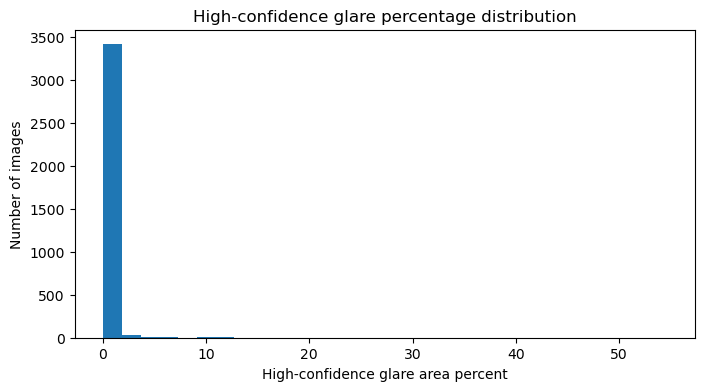

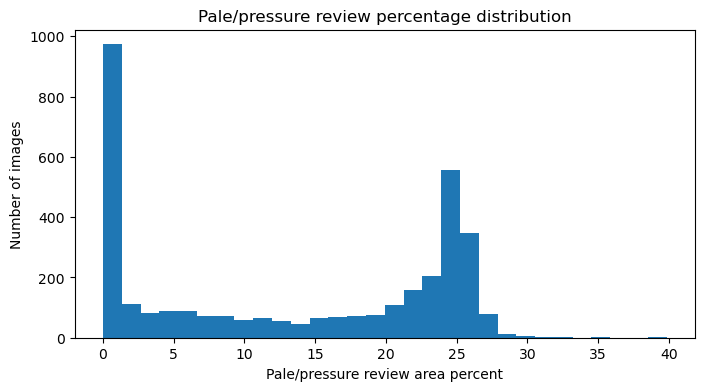

In [5]:
summary = report_df.groupby(["method_used", "status"], dropna=False).size().reset_index(name="count")
display(summary)

if len(report_df) > 0:
    g = pd.to_numeric(report_df["high_conf_glare_area_percent"], errors="coerce")
    p = pd.to_numeric(report_df["pale_pressure_area_percent"], errors="coerce")

    print("High-confidence glare %")
    print("  Mean  :", g.mean())
    print("  Median:", g.median())
    print("  Max   :", g.max())
    print()
    print("Pale/pressure review %")
    print("  Mean  :", p.mean())
    print("  Median:", p.median())
    print("  Max   :", p.max())
    print("  Review count:", report_df["pale_pressure_review"].sum())

    plt.figure(figsize=(8, 4))
    plt.hist(g.dropna(), bins=30)
    plt.xlabel("High-confidence glare area percent")
    plt.ylabel("Number of images")
    plt.title("High-confidence glare percentage distribution")
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.hist(p.dropna(), bins=30)
    plt.xlabel("Pale/pressure review area percent")
    plt.ylabel("Number of images")
    plt.title("Pale/pressure review percentage distribution")
    plt.show()

## 5. Create review contact sheet

This helps you quickly check whether the red mask is true glare and whether the blue mask is preserved pale/pressure signal.

Preview color meaning:
- **Red** = high-confidence glare, may be modified or transparent in RGBA output
- **Blue** = pale/pressure review, preserved and not modified

In [6]:
def make_contact_sheet_from_previews(preview_dir: Path, out_path: Path, max_images=80, thumb_width=520):
    preview_paths = sorted(preview_dir.glob("*_preview.png"))[:max_images]
    if not preview_paths:
        print("No previews found.")
        return None

    thumbs = []
    for p in preview_paths:
        img = Image.open(p).convert("RGB")
        ratio = thumb_width / img.width
        img = img.resize((thumb_width, int(img.height * ratio)))
        thumbs.append((p.name, img))

    cols = 2
    rows = int(np.ceil(len(thumbs) / cols))
    pad = 20
    label_h = 24
    cell_w = thumb_width + pad
    cell_h = max(img.height for _, img in thumbs) + label_h + pad

    sheet = Image.new("RGB", (cols * cell_w + pad, rows * cell_h + pad), "white")
    draw = ImageDraw.Draw(sheet)

    for idx, (name, img) in enumerate(thumbs):
        r = idx // cols
        c = idx % cols
        x = pad + c * cell_w
        y = pad + r * cell_h
        draw.text((x, y), name[:70], fill=(0, 0, 0))
        sheet.paste(img, (x, y + label_h))

    sheet.save(out_path)
    print("Contact sheet saved to:", out_path)
    return out_path

if MAKE_CONTACT_SHEET:
    contact_path = OUTPUT_DIR / "reflection_review_contact_sheet.png"
    make_contact_sheet_from_previews(PREVIEW_DIR, contact_path, CONTACT_SHEET_MAX_IMAGES)

Contact sheet saved to: /Users/williamtsai/Desktop/NTHU 3.2/special topic/will_data/pre_process/glare/usable_nail_crops_roi102_flat_images_brightened_reflection_refined_output/reflection_review_contact_sheet.png


## 6. Optional: copy only safe processed images

This creates folders containing images that are safe for training according to the refined rule.

`safe_for_training_png` uses processed images.

`safe_for_training_rgba_ignore_png` uses the optional RGBA ignore outputs where:
- background is transparent
- high-confidence glare is transparent
- pale/pressure review pixels remain valid

This excludes images marked as `unusable_too_much_specular_glare`.

In [7]:
SAFE_DIR = OUTPUT_DIR / "safe_for_training_png"
SAFE_RGBA_DIR = OUTPUT_DIR / "safe_for_training_rgba_ignore_png"
SAFE_DIR.mkdir(parents=True, exist_ok=True)
SAFE_RGBA_DIR.mkdir(parents=True, exist_ok=True)

safe_statuses = {
    "ok_no_high_conf_glare",
    "ok_high_conf_glare_inpainted",
    "warning_large_high_conf_glare_softened",
}

safe_count = 0
safe_rgba_count = 0
for _, row in report_df.iterrows():
    if row["status"] in safe_statuses and row["processed_path"]:
        src = Path(row["processed_path"])
        if src.exists():
            shutil.copy2(src, SAFE_DIR / src.name)
            safe_count += 1

        if SAVE_RGBA_IGNORE_OUTPUT and row.get("rgba_ignore_path", ""):
            rgba_src = Path(row["rgba_ignore_path"])
            if rgba_src.exists():
                shutil.copy2(rgba_src, SAFE_RGBA_DIR / rgba_src.name)
                safe_rgba_count += 1

print(f"Copied {safe_count} processed safe images to:", SAFE_DIR)
if SAVE_RGBA_IGNORE_OUTPUT:
    print(f"Copied {safe_rgba_count} RGBA ignore safe images to:", SAFE_RGBA_DIR)

Copied 3448 processed safe images to: /Users/williamtsai/Desktop/NTHU 3.2/special topic/will_data/pre_process/glare/usable_nail_crops_roi102_flat_images_brightened_reflection_refined_output/safe_for_training_png
Copied 3448 RGBA ignore safe images to: /Users/williamtsai/Desktop/NTHU 3.2/special topic/will_data/pre_process/glare/usable_nail_crops_roi102_flat_images_brightened_reflection_refined_output/safe_for_training_rgba_ignore_png


## 7. How to judge results

Good result:
- Red mask mostly covers sharp white reflection spots, not broad pale nailbed.
- Blue mask may cover pale/pressure-looking regions, but the processed image keeps them unchanged.
- Nail color still looks natural.
- Nail edges are unchanged.
- Image size is unchanged.
- RGBA ignore output makes only background/high-confidence glare transparent.

Bad result:
- Large pale nailbed regions become red.
- Pressure-blanched but still usable nail regions are removed or inpainted.
- Nail becomes gray, plastic-looking, or smeared.
- Many images are marked `soften` or `unusable_too_much_specular_glare` even when glare is small.

Recommended first review:
1. Open `reflection_review_contact_sheet.png`.
2. Sort `reflection_report.csv` by `high_conf_glare_area_percent` descending.
3. Sort again by `pale_pressure_area_percent` descending.
4. Manually inspect images in `review_pale_or_pressure_possible`.
5. For CNN training with transparency, use `safe_for_training_rgba_ignore_png`.